In [1]:
%pip install -U microlens_submit
%pip install -U RTModel==3.3
%pip install -U jacscanomaly
%pip install -U microjax
%pip install pyAethra

%pip install seaborn

  Using cached microlens_submit-0.17.9-py3-none-any.whl.metadata (10 kB)
Using cached microlens_submit-0.17.9-py3-none-any.whl (1.1 MB)
  Attempting uninstall: microlens_submit
    Found existing installation: microlens-submit 0.16.4
    Uninstalling microlens-submit-0.16.4:
      Successfully uninstalled microlens-submit-0.16.4

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached rtmodel-3.3-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (4.5 kB)
Using cached rtmodel-3.3-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (1.9 MB)
  Attempting uninstall: RTModel
    Found existing installation: RTModel 3.1
    Uninstalling RTModel-3.1:
      Successfully uninstalled RTModel-3.1

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart th

In [17]:
# system imports
import os
import time
import sys
from pathlib import Path

# data access imports
from huggingface_hub import hf_hub_download
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# display imports
from IPython.display import HTML

# multiprocessing imports
import multiprocessing as mp
from multiprocessing.pool import ThreadPool

# data challenge imports
import microlens_submit
#import MulensModel
import emcee
#from pyLIMA.pyLIMASS import SourceLensProbabilities
import RTModel

# data analysis/visualization imports
import numpy as np
import matplotlib.pyplot as plt

# detection packages
from pyAethra import load_config, load_and_run
from jacscanomaly import CandidateCriteria, Finder, FinderConfig

root_dir = '/home/mldc-ipacpeople-admin/teams/mldc-ipacpeople'

In [3]:
# following extra instructions for data download from https://huggingface.co/datasets/RGES-PIT/MachineLearning
%pip install datasets pandas pyarrow duckdb huggingface_hub
#export HF_TOKEN="hf_your_token_here"


/opt/conda/envs/rges-pit-dc/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


  Using cached datasets-5.0.1-py3-none-any.whl.metadata (23 kB)
  Using cached duckdb-1.5.5-cp311-cp311-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl.metadata (4.2 kB)
  Using cached xxhash-4.0.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (17 kB)
Using cached datasets-5.0.1-py3-none-any.whl (559 kB)
Using cached duckdb-1.5.5-cp311-cp311-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl (21.5 MB)
Using cached xxhash-4.0.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (261 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [datasets]2/3 [datasets]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
from datasets import load_dataset
import os

os.environ["HF_TOKEN"] = "your_actual_token_here"

token = os.environ.get("HF_TOKEN")
assert token, "Set HF_TOKEN environment variable first"

dataset_name = "RGES-PIT/MachineLearning"

# Load metadata and epochs tables (which fit easily in RAM)
meta_df = load_dataset(dataset_name, "metadata", split="train", token=token).to_pandas()
epochs_df = load_dataset(dataset_name, "epochs", split="train", token=token).to_pandas()

print(f"Metadata     : {meta_df.shape[0]:,} rows")
print(f"Epochs       : {epochs_df.shape[0]:,} rows")


Metadata     : 377,999 rows
Epochs       : 98,974 rows


In [5]:
meta_df

,name,event_id,sim_label,SubRun,Field,EventID,final_weight,ObsGroup_0_chi2,t0lens1,tE_ref,...,Source_Fe_H,Source2_Mass,Source2_Dist,Source2_Teff,Source2_logg,Source2_Fe_H,is_out_of_season,extinction_F146,extinction_F087,extinction_F213
0,RMDC26_003000,3000,RMDC26_1S1L_ML,0.0,633.0,1936.0,0.012366,66.744210,2.462736e+06,3.585315,...,0.319104,NaN,NaN,NaN,NaN,NaN,False,2.061971,5.147735,0.692188
1,RMDC26_003016,3016,RMDC26_1S1L_ML,0.0,718.0,7002.0,0.021194,13124.511426,2.462735e+06,0.214467,...,0.120387,NaN,NaN,NaN,NaN,NaN,False,0.483870,1.207987,0.162431
2,RMDC26_003032,3032,RMDC26_1S1L_ML,0.0,874.0,572.0,0.016154,3438.811691,2.461841e+06,0.051493,...,-0.556216,NaN,NaN,NaN,NaN,NaN,False,0.848105,2.117306,0.284703
3,RMDC26_003048,3048,RMDC26_1S1L_ML,2.0,0.0,4028.0,0.013090,379.330478,2.461504e+06,14.050508,...,0.080757,NaN,NaN,NaN,NaN,NaN,False,3.180586,7.940372,1.067699
4,RMDC26_003064,3064,RMDC26_1S1L_ML,1.0,21.0,7425.0,0.034964,103.546626,2.461713e+06,36.203618,...,-0.110039,NaN,NaN,NaN,NaN,NaN,True,2.581654,6.445132,0.866642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377994,RMDC26_384935,384935,RMDC26_2S2L_ML,1.0,918.0,81.0,0.179904,1774.770527,2.462784e+06,9.992783,...,0.347771,0.508594,8.585019,3642.0633,4.780081,0.347771,False,0.675996,1.687633,0.226927
377995,RMDC26_384951,384951,RMDC26_2S2L_ML,9.0,839.0,135.0,0.061461,223.086016,2.461851e+06,18.258675,...,0.251984,0.149794,8.099978,2853.6476,5.120895,0.251984,False,0.631576,1.576737,0.212015
377996,RMDC26_384967,384967,RMDC26_2S2L_ML,5.0,49.0,139.0,0.002384,11644.003410,2.461874e+06,3.280384,...,0.464354,NaN,NaN,NaN,NaN,NaN,False,0.691602,1.726592,0.232166
377997,RMDC26_384983,384983,RMDC26_2S2L_ML,5.0,874.0,411.0,0.085583,4561.931445,2.461884e+06,8.112539,...,-0.322607,0.446117,9.057338,3819.0020,4.833098,-0.322607,True,1.476690,3.686576,0.495714


In [6]:
epochs_df

,epoch_id,bjd,obs_x,obs_y,obs_z
0,0,2.461448e+06,-0.787730,0.613210,0.005062
1,1,2.461448e+06,-0.790863,0.609200,0.005066
2,2,2.461448e+06,-0.793980,0.605173,0.005070
3,3,2.461449e+06,-0.800147,0.597080,0.005074
4,4,2.461449e+06,-0.803200,0.593010,0.005076
...,...,...,...,...,...
98969,98969,2.462597e+06,-0.974904,-0.261480,-0.004752
98970,98970,2.462602e+06,-0.950344,-0.343808,-0.004996
98971,98971,2.462607e+06,-0.918830,-0.423583,-0.005084
98972,98972,2.462612e+06,-0.880622,-0.500253,-0.005014


In [7]:
import duckdb
from huggingface_hub import HfFileSystem
import os

token = os.environ.get("HF_TOKEN")
con = duckdb.connect()
con.register_filesystem(HfFileSystem(token=token))

obs_p = "hf://datasets/RGES-PIT/MachineLearning/RMDC26_ML_Data_obs.parquet"
meta_p = "hf://datasets/RGES-PIT/MachineLearning/RMDC26_ML_Data_meta.parquet"
epoch_p = "hf://datasets/RGES-PIT/MachineLearning/RMDC26_ML_Data_epoch.parquet"

event_id = 3000

# Reconstruct a single event's lightcurve
event_obs = con.execute(f"""
    SELECT 
        o.event_id,
        m.name,
        e.bjd,
        o.filt,
        o.flux_uJy,
        m.tE_helio,
        m.sim_label
    FROM '{obs_p}' o
    JOIN '{epoch_p}' e ON o.epoch_id = e.epoch_id
    JOIN '{meta_p}' m ON o.event_id = m.event_id
    WHERE o.event_id = {event_id}
    ORDER BY e.bjd
""").df()

print(f"Event {event_id}: {event_obs['name'].iloc[0]} ({event_obs['sim_label'].iloc[0]})")
print(f"  {len(event_obs):,} observations")
print(f"  Einstein timescale tE_helio = {abs(event_obs['tE_helio'].iloc[0]):.2f} days")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Event 3000: RMDC26_003000 (RMDC26_1S1L_ML)
  49,488 observations
  Einstein timescale tE_helio = 3.55 days


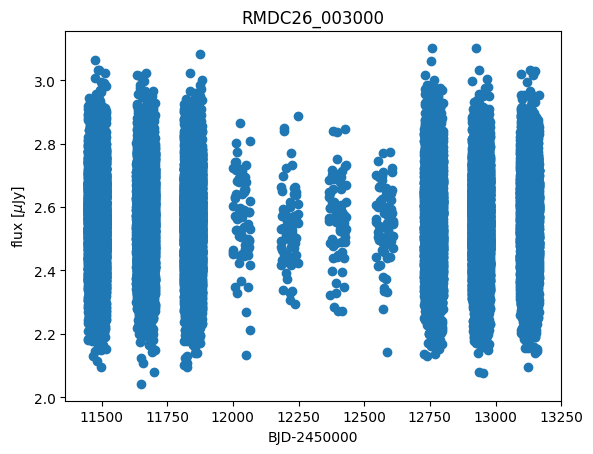

In [7]:
event_obs['bjd-2450000'] = event_obs['bjd'] - 2450000
event_obs_filt = event_obs.loc[event_obs['filt']=='F146']
plt.scatter(event_obs_filt['bjd-2450000'], event_obs_filt['flux_uJy'])
plt.ylabel(r'flux [$\mu$Jy]')
plt.xlabel('BJD-2450000')
plt.title(f"{event_obs['name'].iloc[0]}")
plt.show()

In [8]:
meta_df.columns

Index(['name', 'event_id', 'sim_label', 'SubRun', 'Field', 'EventID',
       'final_weight', 'ObsGroup_0_chi2', 't0lens1', 'tE_ref', 'tE_helio',
       'u0lens1', 'rho', 'alpha', 'piE', 'piEE', 'piEN', 'piEll', 'piErp',
       'rE', 'thetaE', 'ra_deg', 'dec_deg', 'galactic_l', 'galactic_b',
       'murel_helio_alpha', 'murel_helio_delta', 'murel_helio_l',
       'murel_helio_b', 'fs_F146', 'fs_F087', 'fs_F213', 'fs2_F146',
       'fs2_F087', 'fs2_F213', 'Lens_F146', 'Lens_F087', 'Lens_F213',
       'Source_F146', 'Source_F087', 'Source_F213', 'Source2_F146',
       'Source2_F087', 'Source2_F213', 'Source_Is_Binary', 'Source_q',
       'Source_combined_logP', 'Source_total_mass', 'Source2_rho', 'Source2_s',
       'Source2_alpha', 'Source2_inc', 'Source2_phase', 'Planet_mass',
       'Planet_q', 'Planet_s', 'Planet_period', 'Planet_semimajoraxis',
       'Planet_orbphase', 'Planet_inclination', 'Lens_Mass', 'Lens_Dist',
       'Lens_Teff', 'Lens_logg', 'Lens_Fe_H', 'Source_Mass', 'Sourc

In [9]:
meta_df[['name','event_id','sim_label']]

,name,event_id,sim_label
0,RMDC26_003000,3000,RMDC26_1S1L_ML
1,RMDC26_003016,3016,RMDC26_1S1L_ML
2,RMDC26_003032,3032,RMDC26_1S1L_ML
3,RMDC26_003048,3048,RMDC26_1S1L_ML
4,RMDC26_003064,3064,RMDC26_1S1L_ML
...,...,...,...
377994,RMDC26_384935,384935,RMDC26_2S2L_ML
377995,RMDC26_384951,384951,RMDC26_2S2L_ML
377996,RMDC26_384967,384967,RMDC26_2S2L_ML
377997,RMDC26_384983,384983,RMDC26_2S2L_ML


In [14]:
np.unique(meta_df['sim_label'])

array(['RMDC26_1S1L_ML', 'RMDC26_1S2L_ML', 'RMDC26_2S2L_ML'], dtype=object)

In [8]:
meta_df_1s2l = meta_df.loc[(meta_df['sim_label']=='RMDC26_1S2L_ML')]
meta_df_1s2l

,name,event_id,sim_label,SubRun,Field,EventID,final_weight,ObsGroup_0_chi2,t0lens1,tE_ref,...,Source_Fe_H,Source2_Mass,Source2_Dist,Source2_Teff,Source2_logg,Source2_Fe_H,is_out_of_season,extinction_F146,extinction_F087,extinction_F213
18695,RMDC26_306456,306456,RMDC26_1S2L_ML,5.0,88.0,161.0,0.004666,2905.396867,2.463174e+06,12.436439,...,-0.665622,NaN,NaN,NaN,NaN,NaN,True,0.488442,1.219401,0.163966
18696,RMDC26_306472,306472,RMDC26_1S2L_ML,1.0,916.0,442.0,0.008321,1887.063475,2.461828e+06,30.752139,...,0.106405,NaN,NaN,NaN,NaN,NaN,False,0.704850,1.759666,0.236613
18697,RMDC26_306488,306488,RMDC26_1S2L_ML,8.0,877.0,768.0,0.021125,5393.324667,2.462935e+06,49.493615,...,-0.136265,NaN,NaN,NaN,NaN,NaN,False,0.499110,1.246033,0.167547
18698,RMDC26_306504,306504,RMDC26_1S2L_ML,0.0,634.0,123.0,0.009865,2679.048659,2.463146e+06,25.844615,...,-0.064195,NaN,NaN,NaN,NaN,NaN,False,2.999992,7.489517,1.007075
18699,RMDC26_306520,306520,RMDC26_1S2L_ML,7.0,48.0,395.0,0.005591,51081.451737,2.462192e+06,2.685336,...,0.430370,NaN,NaN,NaN,NaN,NaN,True,0.406146,1.013948,0.136340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375314,RMDC26_342023,342023,RMDC26_1S2L_ML,1.0,754.0,471.0,0.010119,596.386791,2.463079e+06,13.299357,...,0.414304,NaN,NaN,NaN,NaN,NaN,True,1.328165,3.315781,0.445855
375315,RMDC26_342039,342039,RMDC26_1S2L_ML,4.0,676.0,869.0,0.008407,138023.979042,2.461720e+06,24.371962,...,0.024497,NaN,NaN,NaN,NaN,NaN,True,0.742187,1.852880,0.249147
375316,RMDC26_342055,342055,RMDC26_1S2L_ML,3.0,917.0,4.0,0.000568,123.205793,2.461861e+06,9.028149,...,0.355993,NaN,NaN,NaN,NaN,NaN,False,0.556260,1.388709,0.186732
375317,RMDC26_342071,342071,RMDC26_1S2L_ML,7.0,640.0,282.0,0.081258,70218.204734,2.462782e+06,36.248093,...,-0.222894,NaN,NaN,NaN,NaN,NaN,False,0.357378,0.892198,0.119969


In [8]:
np.unique(meta_df['EventID'])

array([0.000e+00, 1.000e+00, 2.000e+00, ..., 9.997e+03, 9.998e+03,
       9.999e+03], shape=(10000,))

In [9]:
event_ids = np.unique(meta_df_1s2l['event_id'])
print(len(event_ids))

35647


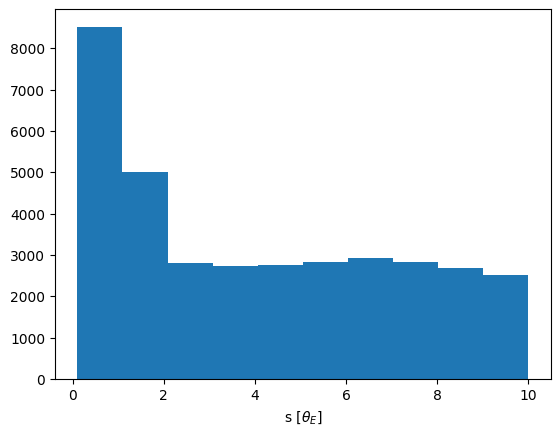

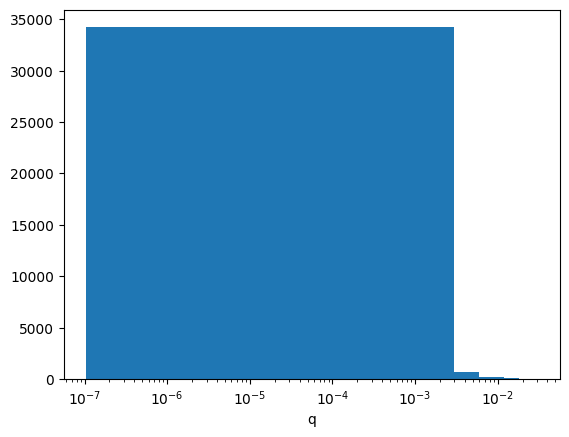

In [10]:
plt.hist(meta_df_1s2l['Planet_s'])
plt.xlabel(r's [$\theta_E$]')
plt.show()

plt.hist(meta_df_1s2l['Planet_q'])
plt.xscale('log')
plt.xlabel('q')
plt.show()

We have way more events than we know what to do with. Let's build a manifest of true events and, from these, identified events and anomalies. 

Let's do this based on true s,q.


In [10]:
# s_bins = np.concat([np.linspace(0, 2, 21), np.linspace(2.2, 6, 20), np.linspace(6.5, 10, 8)])
# q_bins = np.logspace(-7, -2, 50)
s_bins = np.concat([np.linspace(0.2, 2, 10), np.linspace(2.5, 6, 8), np.linspace(7, 10, 4)])
q_bins = np.logspace(-7, -2, 20)

In [11]:
# bin by s and q
meta_df_1s2l['s_bin'] = pd.cut(meta_df_1s2l['Planet_s'], bins=s_bins)
meta_df_1s2l['q_bin'] = pd.cut(meta_df_1s2l['Planet_q'], bins=q_bins)

# 2D groupby and sample 100 or however many events are in that 2D bin, whichever is smaller
samples_2d = 100
meta_df_1s2l_sampled = meta_df_1s2l.groupby(['s_bin', 'q_bin'], observed=False).apply(
    lambda g: g.sample(n=min(len(g), samples_2d)) if len(g) > 0 else g
).reset_index(drop=True)

print(meta_df_1s2l_sampled.groupby(['s_bin', 'q_bin'], observed=False).size())

/tmp/ipykernel_632/1069285110.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta_df_1s2l['s_bin'] = pd.cut(meta_df_1s2l['Planet_s'], bins=s_bins)
/tmp/ipykernel_632/1069285110.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta_df_1s2l['q_bin'] = pd.cut(meta_df_1s2l['Planet_q'], bins=q_bins)


s_bin        q_bin               
(0.2, 0.4]   (1e-07, 1.83e-07]         0
             (1.83e-07, 3.36e-07]      1
             (3.36e-07, 6.16e-07]      1
             (6.16e-07, 1.13e-06]      2
             (1.13e-06, 2.07e-06]      2
                                    ... 
(9.0, 10.0]  (0.000483, 0.000886]    100
             (0.000886, 0.00162]     100
             (0.00162, 0.00298]       63
             (0.00298, 0.00546]       56
             (0.00546, 0.01]          27
Length: 399, dtype: int64


/tmp/ipykernel_632/1069285110.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  meta_df_1s2l_sampled = meta_df_1s2l.groupby(['s_bin', 'q_bin'], observed=False).apply(


In [12]:
meta_df_1s2l_sampled

,name,event_id,sim_label,SubRun,Field,EventID,final_weight,ObsGroup_0_chi2,t0lens1,tE_ref,...,Source2_Dist,Source2_Teff,Source2_logg,Source2_Fe_H,is_out_of_season,extinction_F146,extinction_F087,extinction_F213,s_bin,q_bin
0,RMDC26_319702,319702,RMDC26_1S2L_ML,3.0,794.0,973.0,0.002241,1205.538654,2.461488e+06,4.231731,...,NaN,NaN,NaN,NaN,False,0.707898,1.767275,0.237636,"(0.2, 0.4]","(1.83e-07, 3.36e-07]"
1,RMDC26_324342,324342,RMDC26_1S2L_ML,5.0,677.0,445.0,0.000883,72.510787,2.463109e+06,2.397162,...,NaN,NaN,NaN,NaN,False,0.527304,1.316420,0.177012,"(0.2, 0.4]","(3.36e-07, 6.16e-07]"
2,RMDC26_321490,321490,RMDC26_1S2L_ML,3.0,675.0,101.0,0.001222,1113.725615,2.463144e+06,2.724103,...,NaN,NaN,NaN,NaN,False,1.050797,2.623328,0.352745,"(0.2, 0.4]","(6.16e-07, 1.13e-06]"
3,RMDC26_321164,321164,RMDC26_1S2L_ML,0.0,591.0,4.0,0.000795,2731.668684,2.462222e+06,4.351505,...,NaN,NaN,NaN,NaN,True,3.183634,7.947981,1.068722,"(0.2, 0.4]","(6.16e-07, 1.13e-06]"
4,RMDC26_309512,309512,RMDC26_1S2L_ML,0.0,596.0,207.0,0.003071,64.953973,2.461517e+06,7.103636,...,NaN,NaN,NaN,NaN,False,0.741425,1.850978,0.248891,"(0.2, 0.4]","(1.13e-06, 2.07e-06]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20243,RMDC26_330845,330845,RMDC26_1S2L_ML,9.0,639.0,744.0,0.067610,246.978414,2.462381e+06,6.838604,...,NaN,NaN,NaN,NaN,True,0.315468,0.787569,0.105900,"(9.0, 10.0]","(0.00546, 0.01]"
20244,RMDC26_340311,340311,RMDC26_1S2L_ML,2.0,122.0,941.0,0.017843,504.138191,2.461825e+06,5.679712,...,NaN,NaN,NaN,NaN,False,2.213608,5.526301,0.743092,"(9.0, 10.0]","(0.00546, 0.01]"
20245,RMDC26_313259,313259,RMDC26_1S2L_ML,2.0,795.0,608.0,0.009383,1668.182136,2.461444e+06,57.891546,...,NaN,NaN,NaN,NaN,True,0.854963,2.134427,0.287005,"(9.0, 10.0]","(0.00546, 0.01]"
20246,RMDC26_337809,337809,RMDC26_1S2L_ML,5.0,46.0,404.0,0.004481,6127.442650,2.462394e+06,3.634358,...,NaN,NaN,NaN,NaN,True,0.905255,2.259981,0.303887,"(9.0, 10.0]","(0.00546, 0.01]"


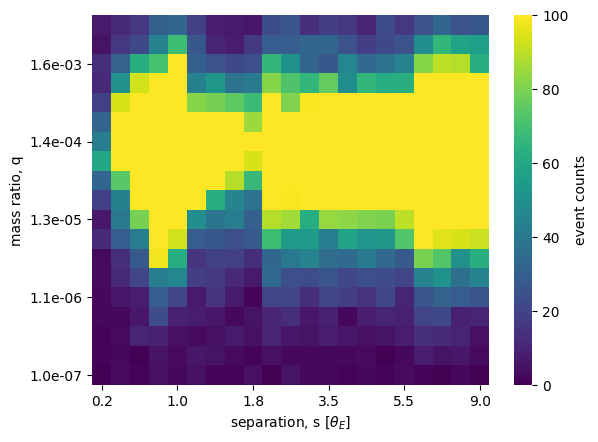

In [13]:
import seaborn as sns

# event counts per s, q bin
heatmap_data = pd.crosstab(meta_df_1s2l_sampled["s_bin"], meta_df_1s2l_sampled["q_bin"]).T

# prep axis labels cause we boutta aesthetize
y_labels = q_bins[:-1]
x_labels = s_bins[:-1]

# plot heatmap
ax = sns.heatmap(
    heatmap_data, annot=False, fmt="d", cmap="viridis", xticklabels=False, yticklabels=False,
    cbar_kws={"label": "event counts"}
)
ax.invert_yaxis() 

# show every 4th tick, and place ticks at center of corresponding cells
x_ticks = np.arange(len(x_labels))[::4] + 0.5
y_ticks = np.arange(len(y_labels))[::4] + 0.5
ax.set_xticks(x_ticks)
ax.set_xticklabels([x_labels[int(i)] for i in np.arange(len(x_labels))[::4]])
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{y_labels[int(i)]:.1e}" for i in np.arange(len(y_labels))[::4]])

ax.set_xlabel(r"separation, s [$\theta_E$]")
ax.set_ylabel("mass ratio, q")
plt.show()

This is essentially our denominator

Run PIT pipeline on all events in this subset

In [30]:
aethra_config = load_config(root_dir+"/config/aethra_config.yaml") # courtesy of Katie Vandorou
aethra_config = {
    "time_col": "bjd",
    "flux_col":     "flux_uJy",
    "flux_err_col": "flux_err_uJy",
    "group_col": "name"
}

def detection(lc_data, f146_df, labels, t0s, tEs, u0s, t0_anomalies, jacscanomaly_scores):#, ss, qs, alphas, rhos):

    ### EVENT DETECTION WITH PYAETHRA
    aethra_results_df = load_and_run(lc_data, aethra_config)
    label = aethra_results_df['label'].iloc[0]
    labels.append(label)
    print("label: ", label)

    ### this is logic for proceeding to next event in the loop if pyAethra fails to find a bound or free-floating planet candidate
    if (label != 'microlensing') and (label != 'ffp'):
        t0s.append(np.nan)
        tEs.append(np.nan)
        u0s.append(np.nan)
        #continue # skip to next event 
        t0_anomalies.append(np.nan)
        jacscanomaly_scores.append(np.nan)
        # ss.append(np.nan)
        # qs.append(np.nan)
        # alphas.append(np.nan)
        # rhos.append(np.nan)

    else:
        t0_fit = aethra_results_df['t0_fit'].iloc[0]
        u0_fit = aethra_results_df['u0_fit'].iloc[0]
        tE_fit = aethra_results_df['tE_fit'].iloc[0]
        print("t0: ", t0_fit)
        print("u0: ", u0_fit)
        print("tE: ", tE_fit)
        t0s.append(t0_fit)
        tEs.append(tE_fit)
        u0s.append(u0_fit)

        ### ANOMALY DETECTION WITH JACSCANOMALY
        time = np.array(f146_df["bjd"])
        flux = np.array(f146_df["flux_uJy"])
        fluxerr = np.array(f146_df["flux_err_uJy"])

        criteria = CandidateCriteria(
            min_dchi2=20.0, 
            min_n_eff=2.0,
            #min_n_contrib=2,
            #max_peak_frac=0.8,
        )
        jacscanomaly_config = FinderConfig(
            fitter_kind="pspl",
            candidate_criteria=criteria, # candidate_criteria=CandidateCriteria(min_n_eff=2.0)
            gap=150.0 # default is 50. gap between seasons is ~half a year, hence 150
        )
        finder = Finder(jacscanomaly_config)

        # initial guess is from aethra
        p0 = np.array([t0_fit, tE_fit, u0_fit]) 

        # actually run the anomaly finder. Make sure you're distinguishing between magnitude and flux. Beginner tier uses mag; experienced+ tiers use flux.
        print("running jacscanomaly...")
        anomaly_result = finder.run(time, flux, fluxerr, p0, data_kind="mag")
        #anomaly_result.print_summary()
        anomaly_result_summary = anomaly_result.summary_table()
        #print(anomaly_result_summary)

        # grab relevant variables
        t0_fit_best = anomaly_result_summary['best_t0'].values[0]
        print("t0_fit_best: ", t0_fit_best)

        best_score = anomaly_result_summary['best_score'].values[0]
        print("best score: ", best_score)
        jacscanomaly_scores.append(best_score)

        # this is where I skip to the next event, if jacscanomaly finds nothing
        if best_score < 10:
            print("does not pass score threshold of 10")
            t0_anomalies.append(np.nan)
        else:
            t0_anomaly = anomaly_result_summary['best_t0'].values[0]
            t0_anomalies.append(t0_anomaly)

    return labels, t0s, tEs, u0s, t0_anomalies, jacscanomaly_scores

306455
Event 306455: RMDC26_306455 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 24.32 days


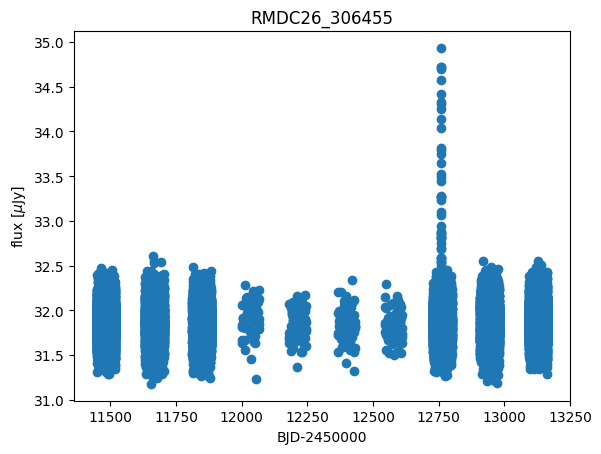

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306456
Event 306456: RMDC26_306456 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 12.39 days


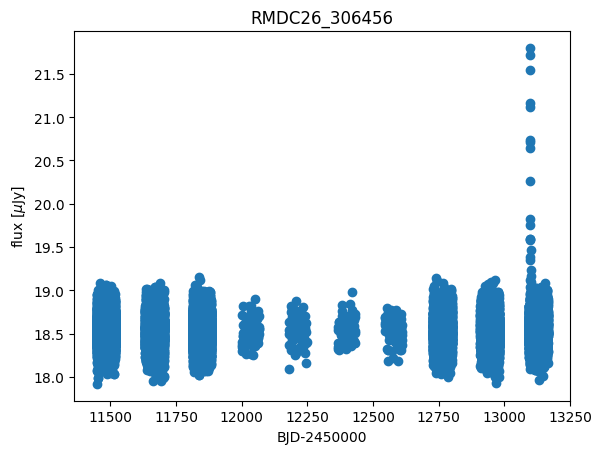

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306457
Event 306457: RMDC26_306457 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 6.90 days


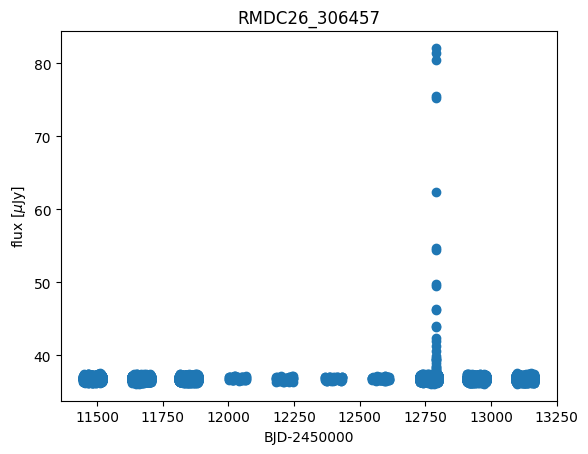

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  microlensing
t0:  12790.849293470848
u0:  0.021378341536500405
tE:  4.989245585049228
running jacscanomaly...
t0_fit_best:  2462774.838570506
best score:  19710.23196489506
306458
Event 306458: RMDC26_306458 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 48.09 days


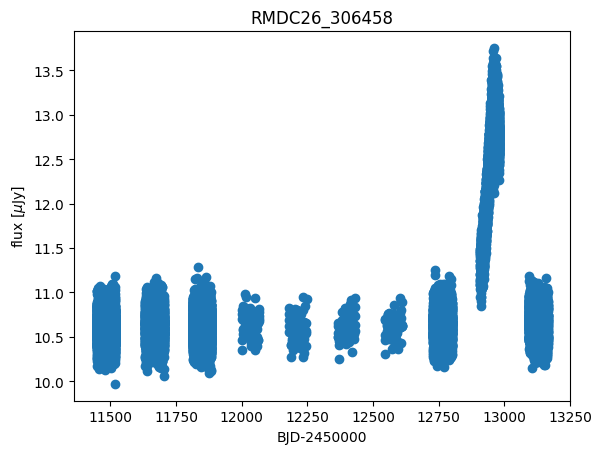

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306459
Event 306459: RMDC26_306459 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 11.38 days


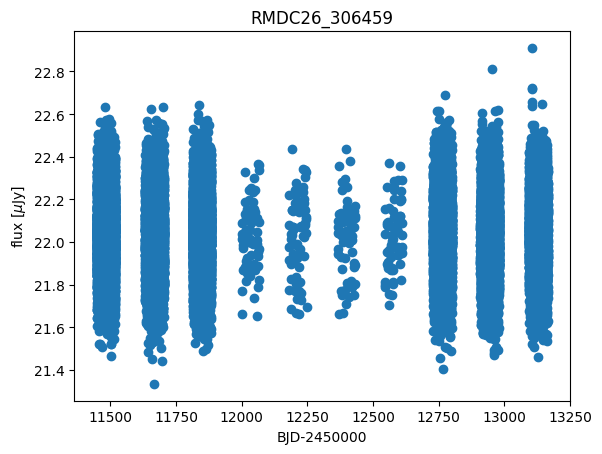

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306460
Event 306460: RMDC26_306460 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 10.85 days


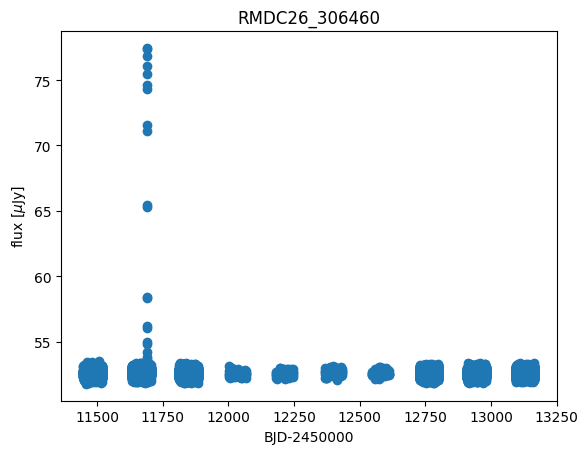

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  microlensing
t0:  11688.279562243726
u0:  0.04865210872786915
tE:  5.851641641227839
running jacscanomaly...
t0_fit_best:  2461679.2840592144
best score:  6456.893217079892
306461
Event 306461: RMDC26_306461 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 10.81 days


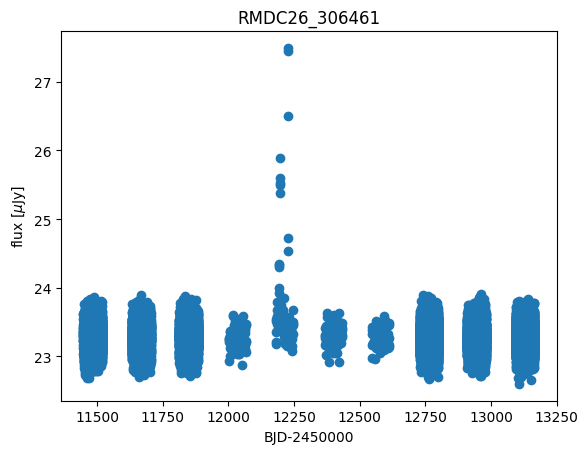

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306462
Event 306462: RMDC26_306462 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 22.47 days


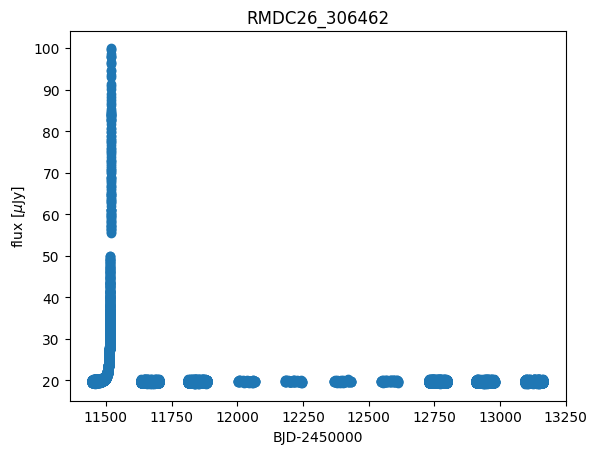

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306463
Event 306463: RMDC26_306463 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 34.65 days


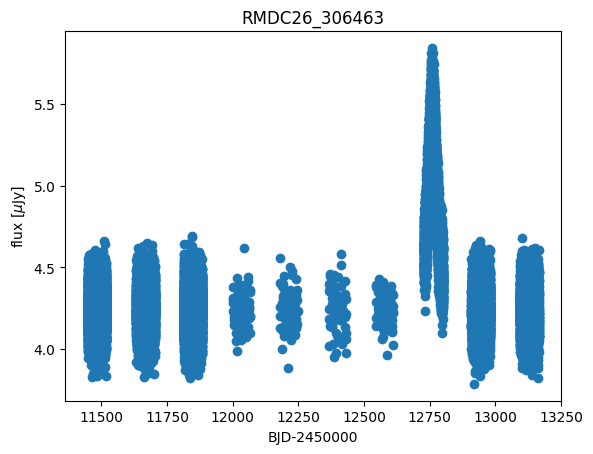

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306464
Event 306464: RMDC26_306464 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 17.21 days


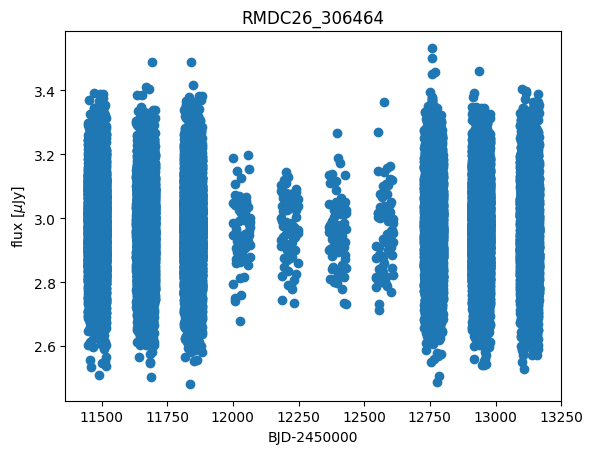

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306465
Event 306465: RMDC26_306465 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 6.03 days


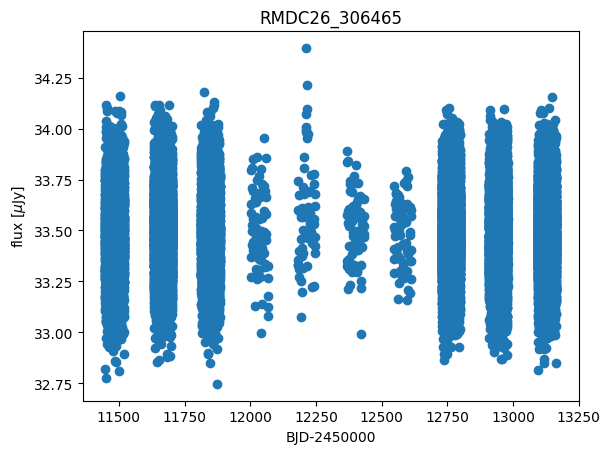

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306466
Event 306466: RMDC26_306466 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 42.51 days


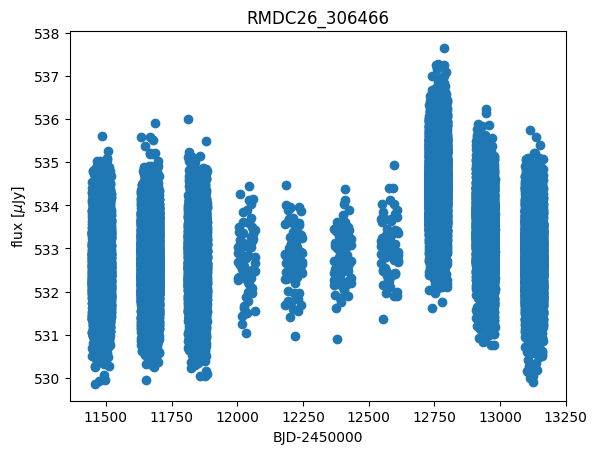

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306467
Event 306467: RMDC26_306467 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 45.76 days


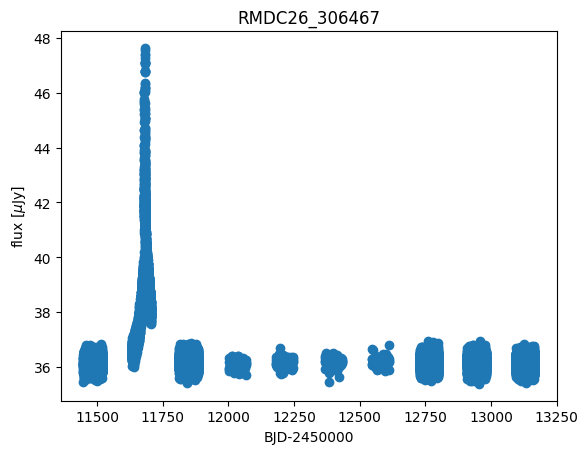

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306468
Event 306468: RMDC26_306468 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 11.10 days


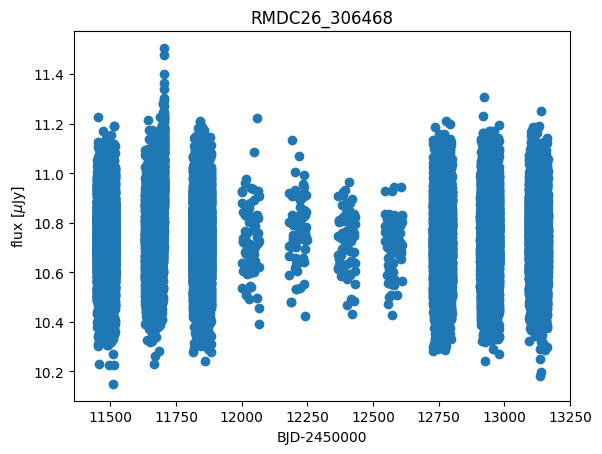

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306469
Event 306469: RMDC26_306469 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 11.31 days


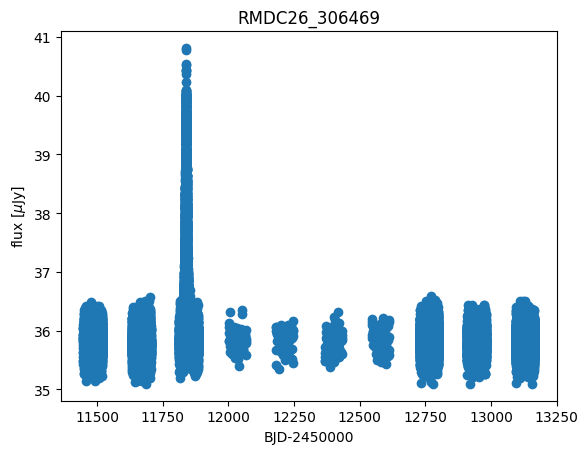

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  microlensing
t0:  11838.308816309087
u0:  0.15676271884201332
tE:  12.418254683173515
running jacscanomaly...
t0_fit_best:  2461839.4476306685
best score:  58936.90205431083
306470
Event 306470: RMDC26_306470 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 3.90 days


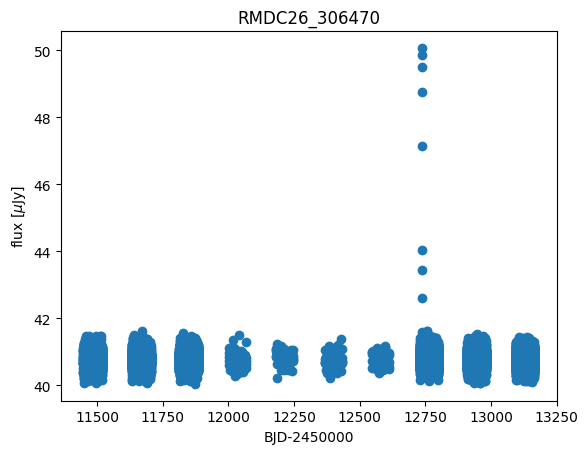

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  microlensing
t0:  12748.64568407461
u0:  1.8483571388150446
tE:  9.015269939052502
running jacscanomaly...
t0_fit_best:  2462732.4255446484
best score:  24791.35305297458
306471
Event 306471: RMDC26_306471 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 7.16 days


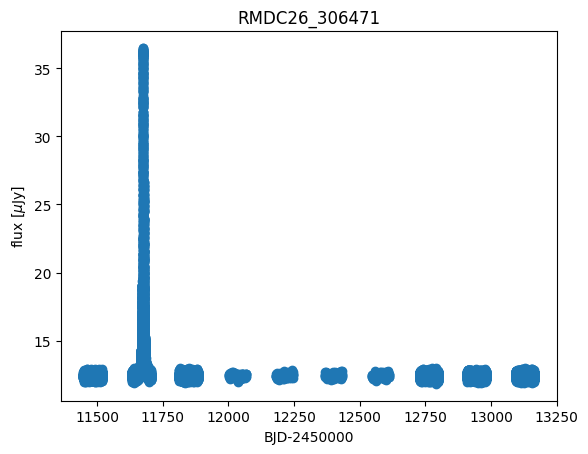

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306472
Event 306472: RMDC26_306472 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 30.70 days


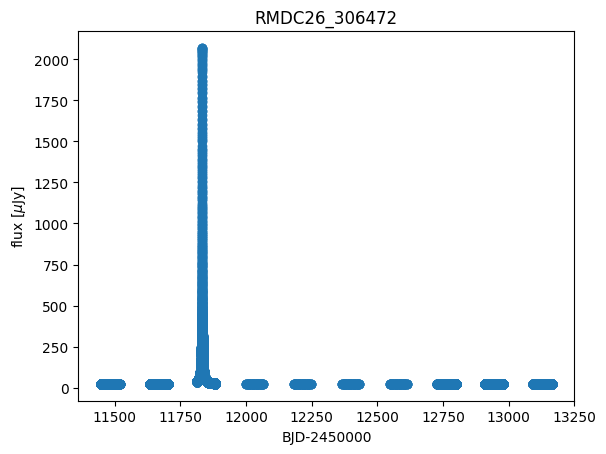

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  microlensing
t0:  11832.743616583291
u0:  0.0077203152063996215
tE:  35.04715079195161
running jacscanomaly...
t0_fit_best:  2461879.5637342534
best score:  16731.64841294065
306473
Event 306473: RMDC26_306473 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 7.56 days


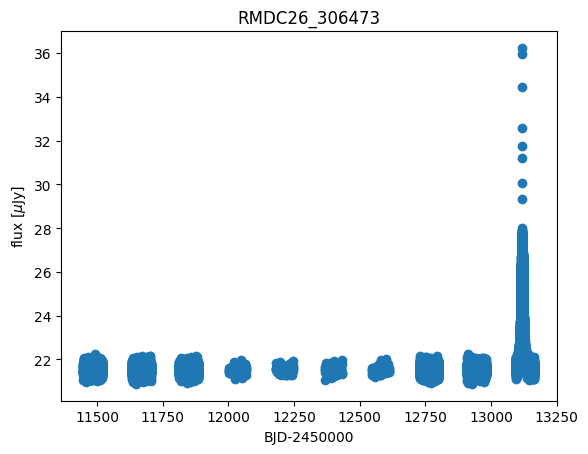

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306474
Event 306474: RMDC26_306474 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 7.87 days


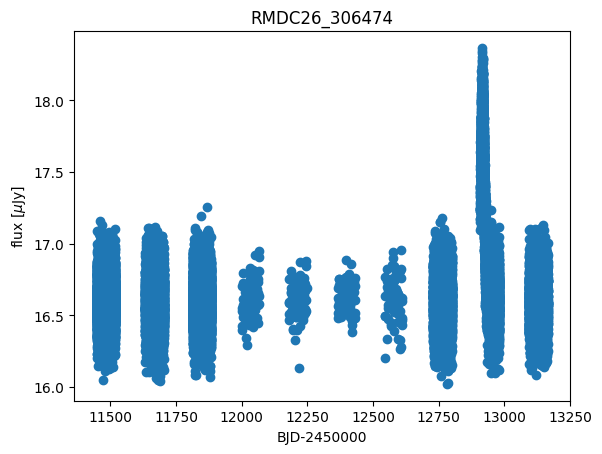

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306475
Event 306475: RMDC26_306475 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 3.91 days


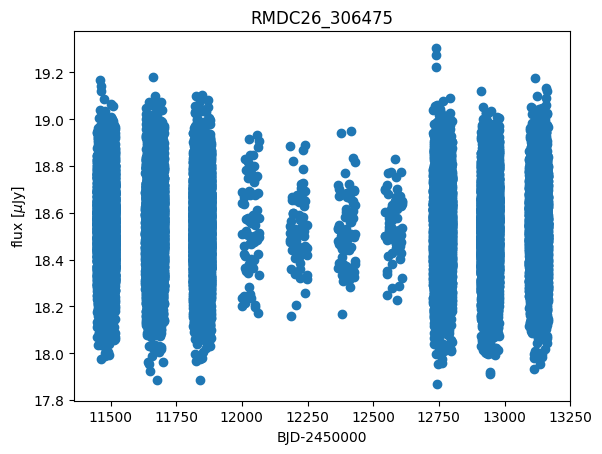

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306476
Event 306476: RMDC26_306476 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 5.55 days


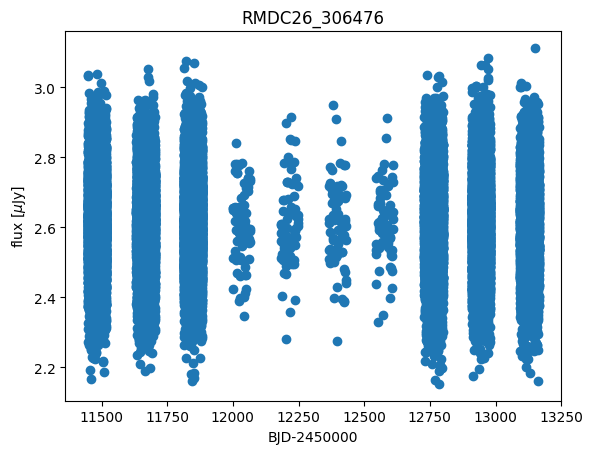

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306477
Event 306477: RMDC26_306477 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 58.88 days


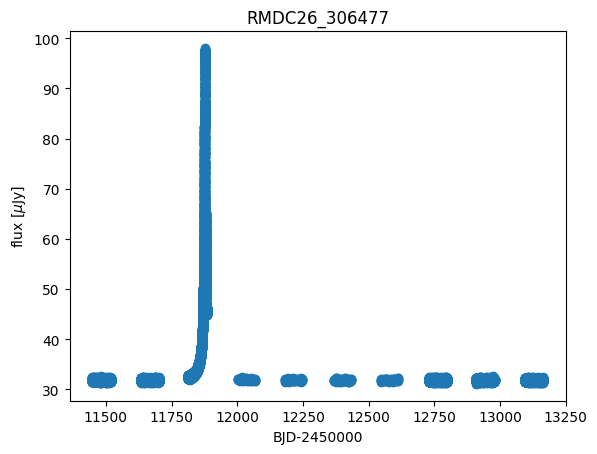

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  microlensing
t0:  11876.55376973562
u0:  0.027099939400910215
tE:  58.850603981448344
running jacscanomaly...
t0_fit_best:  2461827.296650515
best score:  49997.189319852994
306478
Event 306478: RMDC26_306478 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 7.83 days


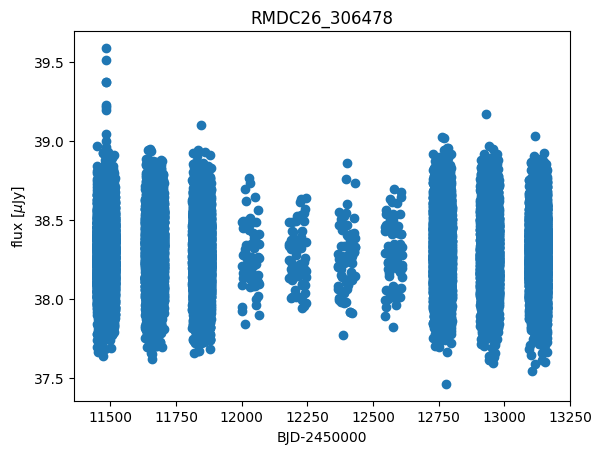

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306479
Event 306479: RMDC26_306479 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 6.24 days


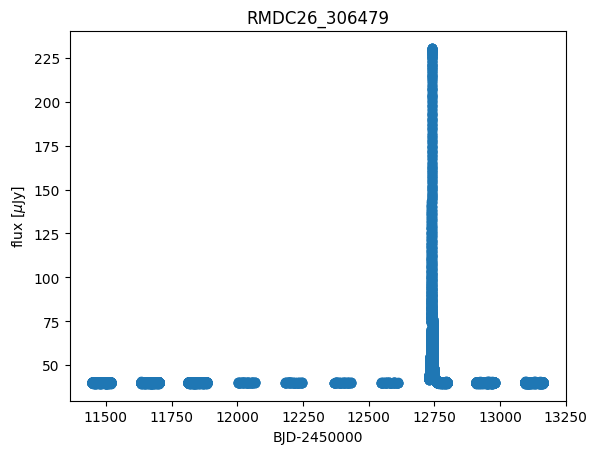

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  microlensing
t0:  12740.62765502138
u0:  0.12317921245027763
tE:  6.31659867407556
running jacscanomaly...
t0_fit_best:  2462785.7945555714
best score:  119908.31120031612
306480
Event 306480: RMDC26_306480 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 24.01 days


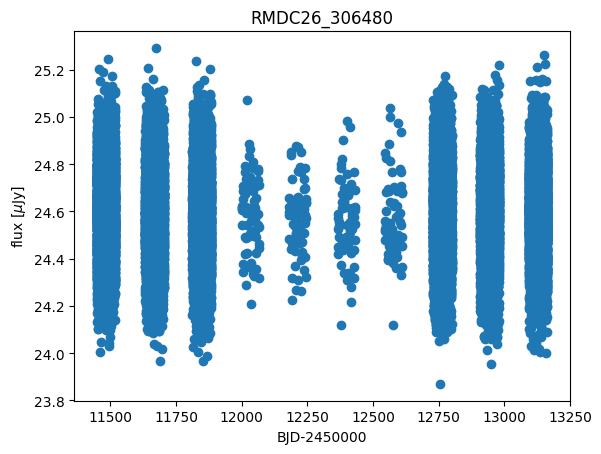

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306481
Event 306481: RMDC26_306481 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 2.65 days


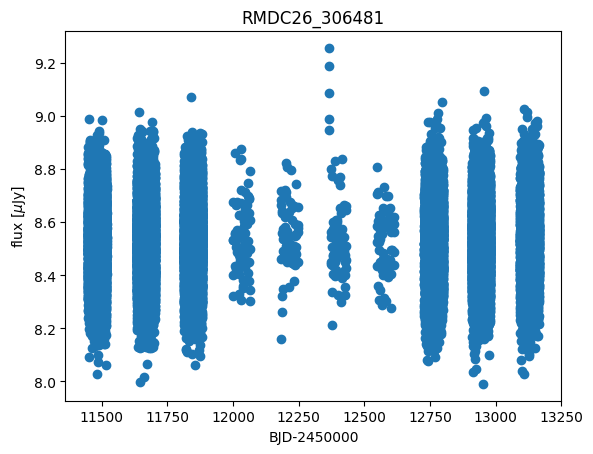

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306482
Event 306482: RMDC26_306482 (RMDC26_1S2L_ML)
  49,488 observations
  Einstein timescale tE_helio = 3.57 days


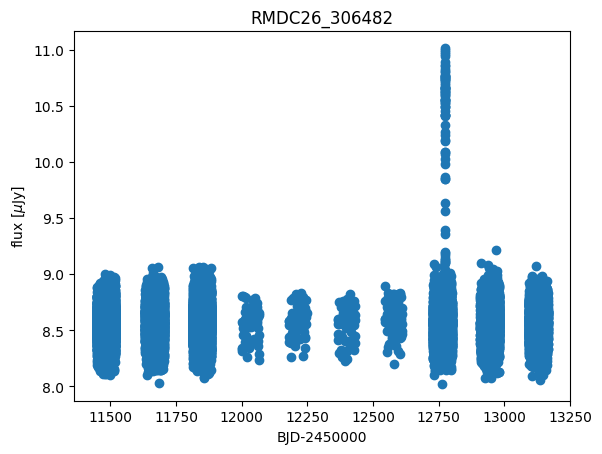

  49,488 rows, columns: ['event_id', 'name', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'tE_helio', 'sim_label', 'bjd-2450000']
label:  variable star
306483


Error: HfHubHTTPError: (Request ID: Root=1-6aa32989-219a93bd1f68ff0148a4757f;47b55200-a0cd-4692-a62f-7cb649b2ae7c)

429 Too Many Requests: you have reached your 'api' rate limit.
Retry after 7 seconds (0/500 requests remaining in current 300s window).
Url: https://huggingface.co/api/datasets/RGES-PIT/MachineLearning/paths-info/main.
We had to rate limit your IP (18.214.131.174). To continue using our service, create a HF account or login to your existing account, and make sure you pass a HF_TOKEN if you're using the API.

At:
  /opt/conda/envs/rges-pit-dc/lib/python3.11/site-packages/huggingface_hub/utils/_http.py(743): hf_raise_for_status
  /opt/conda/envs/rges-pit-dc/lib/python3.11/site-packages/huggingface_hub/hf_api.py(3607): get_paths_info
  /opt/conda/envs/rges-pit-dc/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py(89): _inner_fn
  /opt/conda/envs/rges-pit-dc/lib/python3.11/site-packages/huggingface_hub/hf_file_system.py(809): info
  /opt/conda/envs/rges-pit-dc/

In [31]:
labels, t0s, tEs, u0s, t0_anomalies, jacscanomaly_scores = [], [], [], [], [], []
for event_id in np.unique(meta_df_1s2l['event_id']):
    print(event_id)

    # summon the light curve
    # Reconstruct a single event's lightcurve
    event_obs = con.execute(f"""
        SELECT 
            o.event_id,
            m.name,
            e.bjd,
            o.filt,
            o.flux_uJy,
            o.flux_err_uJy,
            m.tE_helio,
            m.sim_label
        FROM '{obs_p}' o
        JOIN '{epoch_p}' e ON o.epoch_id = e.epoch_id
        JOIN '{meta_p}' m ON o.event_id = m.event_id
        WHERE o.event_id = {event_id}
        ORDER BY e.bjd
    """).df()
    
    print(f"Event {event_id}: {event_obs['name'].iloc[0]} ({event_obs['sim_label'].iloc[0]})")
    print(f"  {len(event_obs):,} observations")
    print(f"  Einstein timescale tE_helio = {abs(event_obs['tE_helio'].iloc[0]):.2f} days")

    event_obs['bjd-2450000'] = event_obs['bjd'] - 2450000
    event_obs_filt = event_obs.loc[event_obs['filt']=='F146']
    plt.scatter(event_obs_filt['bjd-2450000'], event_obs_filt['flux_uJy'])
    plt.ylabel(r'flux [$\mu$Jy]')
    plt.xlabel('BJD-2450000')
    plt.title(f"{event_obs['name'].iloc[0]}")
    plt.show()

    # Detection
    labels, t0s, tEs, u0s, t0_anomalies, jacscanomaly_scores = detection(event_obs, event_obs_filt, labels, t0s, tEs, u0s, t0_anomalies, jacscanomaly_scores)
    
    

In [32]:
labels, t0s, tEs, u0s, t0_anomalies, jacscanomaly_scores

(['variable star',
  'variable star',
  'microlensing',
  'variable star',
  'variable star',
  'microlensing',
  'variable star',
  'variable star',
  'variable star',
  'variable star',
  'variable star',
  'variable star',
  'variable star',
  'variable star',
  'microlensing',
  'microlensing',
  'variable star',
  'microlensing',
  'variable star',
  'variable star',
  'variable star',
  'variable star',
  'microlensing',
  'variable star',
  'microlensing',
  'variable star',
  'variable star',
  'variable star'],
 [nan,
  nan,
  np.float64(12790.849293470848),
  nan,
  nan,
  np.float64(11688.279562243726),
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  np.float64(11838.308816309087),
  np.float64(12748.64568407461),
  nan,
  np.float64(11832.743616583291),
  nan,
  nan,
  nan,
  nan,
  np.float64(11876.55376973562),
  nan,
  np.float64(12740.62765502138),
  nan,
  nan,
  nan],
 [nan,
  nan,
  np.float64(4.989245585049228),
  nan,
  nan,
  np.float64(5.851641641227839

In [33]:
names = []
for event_id in np.unique(meta_df_1s2l['event_id']):
    names.append(event_id)
print(len(names))
    

35647


In [34]:
len(labels)

28

In [ ]:
# large CPU optimized server: <2 hours (however long the IPAC ice cream social was) 
df = pd.DataFrame({'name': names, 'label': labels, 't0': t0s, 'tE': tEs, 'u0': u0s, 't0_anomaly': t0_anomalies, 'jacscanomaly_score': jacscanomaly_scores})
print(df_dsct)
df_dsct.to_csv(path+'data/reliability_wg6_dsct.csv', index=False)

In [3]:
TIER = "MachineLearning"
REPO_ID = f"RGES-PIT/{TIER}"

#FILENAME = f"RMDC26_{TIER}_Tier_obs.parquet"  # "_test" tells hugging face this is not a machine learning training set.
local_data_path = hf_hub_download(repo_id=REPO_ID, filename="RMDC26_ML", repo_type="dataset")
lc_data_all = pd.read_parquet(local_data_path)
print(local_data_path)
print(lc_data_all)
print(lc_data_all.columns)
print(lc_data_all['name'])

RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-6a84f4f9-22b4fa9a725f22f53d9bdccf;af3b8511-6e82-4bf2-aecd-83278c115dbe)

Repository Not Found for url: https://huggingface.co/datasets/RGES-PIT/ML_Data/resolve/main/RMDC26_ML_Data_Tier_obs.parquet.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.

Events in this tier run from 189 to 2288

Normally, we'd take a bunch of light curves and do event detection straight-up. But the data challenge light curves all have the same time stamps, so the best we can do is to iterate one light curve at a time and do event detection --> anomaly detection --> event modeling per "light curve" (but really per event). So, this isn't super representative of our ability to do event detection (or anomaly detection?). 

Especially for RTModel to work, we need to rearrange the file structure, as follows

#### Rearrange file structure

In [5]:
lc_data_all['bjd-2450000'] = lc_data_all['bjd'] - 2450000

In [7]:
lc_data_all

,name,l_deg,b_deg,ra_deg,dec_deg,bjd,filt,flux_uJy,flux_err_uJy,extinction,saturation_flag,measured_ra_deg,measured_dec_deg,measured_ra_err_deg,measured_dec_err_deg,obs_x,obs_y,obs_z,bjd-2450000
0,RMDC26_002067,-0.458321,-1.731208,267.838726,-30.221671,2.461448e+06,F087,10.893037,0.305048,1.946512,0,267.838741,-30.221657,4.257373e-07,3.678730e-07,-0.787729,0.613209,0.005062,11447.917416
1,RMDC26_002067,-0.458321,-1.731208,267.838726,-30.221671,2.461448e+06,F087,11.351664,0.305048,1.946512,0,267.838743,-30.221657,4.184294e-07,3.615584e-07,-0.790864,0.609200,0.005066,11448.204097
2,RMDC26_002067,-0.458321,-1.731208,267.838726,-30.221671,2.461448e+06,F087,11.214074,0.305048,1.946512,0,267.838743,-30.221657,4.205409e-07,3.633829e-07,-0.793979,0.605175,0.005070,11448.490779
3,RMDC26_002067,-0.458321,-1.731208,267.838726,-30.221671,2.461449e+06,F087,11.725116,0.305048,1.946512,0,267.838742,-30.221657,4.130198e-07,3.568840e-07,-0.800147,0.597079,0.005074,11449.064141
4,RMDC26_002067,-0.458321,-1.731208,267.838726,-30.221671,2.461449e+06,F087,11.347292,0.305048,1.946512,0,267.838742,-30.221658,4.184955e-07,3.616154e-07,-0.803201,0.593009,0.005076,11449.350823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102885547,RMDC26_000511,0.807802,-1.012752,267.871272,-28.766507,2.462592e+06,F213,105.943582,0.973274,0.550793,0,267.871276,-28.766506,3.808801e-07,3.338750e-07,-0.992297,-0.177175,-0.004360,12591.550978
102885548,RMDC26_000511,0.807802,-1.012752,267.871272,-28.766507,2.462597e+06,F213,105.074842,0.973274,0.550793,0,267.871276,-28.766507,3.808801e-07,3.338750e-07,-0.974904,-0.261480,-0.004752,12596.550978
102885549,RMDC26_000511,0.807802,-1.012752,267.871272,-28.766507,2.462602e+06,F213,103.194557,0.973274,0.550793,0,267.871276,-28.766507,3.808801e-07,3.338750e-07,-0.950344,-0.343808,-0.004996,12601.550978
102885550,RMDC26_000511,0.807802,-1.012752,267.871272,-28.766507,2.462607e+06,F213,104.269573,0.973274,0.550793,0,267.871276,-28.766507,3.808801e-07,3.338750e-07,-0.918830,-0.423583,-0.005084,12606.550978


/tmp/ipykernel_606/489637128.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lc_data_filt['mag'] = 23.9 - 2.5 * np.log10(lc_data_filt['flux_uJy'])
/tmp/ipykernel_606/489637128.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lc_data_filt['mag_err'] = 23.9 - 2.5 * np.log10(lc_data_filt['flux_err_uJy'])


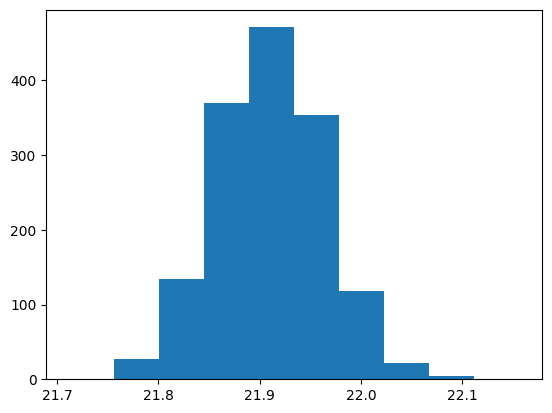

In [17]:
# lc_data_filt['mag'] = 23.9 - 2.5 * np.log10(lc_data_filt['flux_uJy'])
# lc_data_filt['mag_err'] = 23.9 - 2.5 * np.log10(lc_data_filt['flux_err_uJy'])
# plt.hist(lc_data_filt['mag'])
# plt.show()

In [21]:
event_data_me = 'event_data_chris/'

In [30]:
root_dir = '/home/mldc-ipacpeople-admin/teams/mldc-ipacpeople'
filters = ['F087', 'F146', 'F213']
aethra_labels = []
for EVENT_ID in sorted(lc_data_all["name"].unique()):
    print("Working on: ", EVENT_ID)
    
    # pick out event/light curve
    lc_data = lc_data_all[lc_data_all["name"] == EVENT_ID]
    actual_id = EVENT_ID.split("_", 1)[1]
    
    # create event directory in the format RTModel wants
    new_event_dir = root_dir + '/' + event_data_me + 'event_' + actual_id
    try:
        os.mkdir(new_event_dir)
    except Exception as e:
        pass
    try:
        os.mkdir(new_event_dir + '/Data/')
    except Exception as e:
        pass

    # each filter should be converted to a .dat file with the following header: # Mag err HJD-2450000
    # furthermore, RTModel is particular about filename structures: .dat files should end with the correct satelllite suffix
    # name schematics follow the schematic from Stela Ishitani Silva's post on WG3 Confluence page
    # https://rgespit.atlassian.net/wiki/spaces/RPTH/pages/154828801/RTModel+v2.4+Runs+for+the+2371+Representative+Sample+Lightcurves
    for filt in filters:
        lc_data_filt = lc_data.loc[lc_data['filt']==filt]#[time_mask]
        lc_data_dat = pd.DataFrame({'Flux': lc_data_filt['flux_uJy'], 'err': lc_data_filt['flux_err_uJy'], 'HJD-2450000': lc_data_filt['bjd-2450000']})
        if filt=='F087':
            dat_filepath = new_event_dir + '/Data/RomanZ087sat2.dat'
        elif filt=='F146':
            dat_filepath = new_event_dir + '/Data/RomanW146sat1.dat'
        elif filt=='F213':
            dat_filepath = new_event_dir + '/Data/RomanK213sat3.dat'
        with open(dat_filepath, "w", encoding="utf-8") as f:
            f.write("# Mag err HJD-2450000\n")
            lc_data_dat.to_csv(f, sep=' ', header=None, index=False)

    # add coordinates in Data/ dir too     
    coords = SkyCoord(ra=lc_data_filt['ra_deg'].values[0]*u.degree, dec=lc_data_filt['dec_deg'].values[0]*u.degree, frame='icrs')
    ra_hms = coords.ra.to_string(unit=u.hourangle, sep=':', pad=True)
    dec_dms = coords.dec.to_string(sep=':', pad=True)
    coord_filepath = new_event_dir + '/Data/event.coordinates'
    with open(coord_filepath, "w", encoding="utf-8") as cf:
        cf.write(f"{ra_hms} {dec_dms}")

    # add limb darkening file in Data/
    limb_dark_filepath = new_event_dir + '/Data/LimbDarkening.txt'
    with open(limb_dark_filepath, "w", encoding="utf-8") as ld:
        ld.write("0.33 \n0.4532 \n0.251")

    ### event detection
    ### now called Aethra: https://github.com/rges-pit/pyAethra
    aethra_config = load_config(root_dir+"/config/aethra_config.yaml") # courtesy of Katie Vandorou
    # this tier uses flux instead of mag, so change just this part of the config
    aethra_config = {
        "time_col": "bjd",
        "mag_col":  "flux_uJy",
        "err_col":  "flux_err_uJy",
        "group_col": "name",   # column identifying each object in the table
    }
    
    results_df = load_and_run(lc_data, aethra_config)
    label = results_df['label'].iloc[0]
    print("label: ", label)
    aethra_labels.append(label)

    if (label!='microlensing') and (label!='ffp'):
        continue

    print(results_df)
    t0_fit = results_df['t0_fit'].iloc[0]
    u0_fit = results_df['u0_fit'].iloc[0]
    tE_fit = results_df['tE_fit'].iloc[0]
    print("t0: ", t0_fit)
    print("u0: ", u0_fit)
    print("tE: ", tE_fit)
    asdfasdfdsf

    ### anomaly detection
    #lc_data['bjd-2450000'] = lc_data['bjd'] - 2450000
    # masks: jacscanomaly only takes the F146 filter
    time_mask = (lc_data["bjd-2450000"] <= t0_fit + tE_fit * 2) & (lc_data["bjd-2450000"] >= t0_fit - tE_fit * 2)
    filter_mask = lc_data["filt"] == 'F146'
    lc_data_filter_mask = lc_data[filter_mask]
    lc_data_mask = lc_data[time_mask & filter_mask]
    #print("length of masked data: ", len(lc_data_mask), " out of: ", len(lc_data))
    
    # load data (time, flux, flux_err)
    #lc_data_season = lc_data.loc[lc_data['
    time = np.array(lc_data_filter_mask["bjd-2450000"])#[time_mask & filter_mask])
    flux = np.array(lc_data_filter_mask["flux_uJy"])#[time_mask & filter_mask])
    fluxerr = np.array(lc_data_filter_mask["flux_err_uJy"])#[time_mask & filter_mask])
    
    # run anomaly finder
    criteria = CandidateCriteria(
        min_dchi2=60.0,
        min_n_eff=2.0,
        #min_n_contrib=2,
        #max_peak_frac=0.8,
    )
    jacscanomaly_config = FinderConfig(
        fitter_kind="pspl",
        candidate_criteria=criteria, # candidate_criteria=CandidateCriteria(min_n_eff=2.0)
        gap=100.0
    )
    finder = Finder(jacscanomaly_config)

    # initial guess is from aethra
    p0 = np.array([t0_fit, tE_fit, u0_fit])  # t0, tE, u0
    result = finder.run(time, flux, fluxerr, p0, data_kind="flux")
    result.print_summary()
    result_summary = result.summary_table()
    print(result_summary)
    
    ### do a couple checks for no or weak anomaly found 
    if result_summary['has_best'].values[0]==False:
        plt.errorbar(lc_data_filter_mask['bjd-2450000'], lc_data_filter_mask['flux_uJy'], lc_data_filter_mask['flux_err_uJy'], )
        plt.axvline(x=t0_fit, color='red', linestyle='--', linewidth=2, label='event')
        #plt.gca().yaxis.set_inverted(True)
        plt.xlim([t0_fit - 5*tE_fit, t0_fit + 5*tE_fit])
        #plt.xlim([11459-20,11459+120])
        #plt.xlim([11630, 11700])
        plt.ylabel(r'flux [$\micro$Jy]')
        plt.xlabel('BJD-2450000')
        plt.title(f"no anomaly: {EVENT_ID}")
        plt.legend()
        plt.show()
        continue
    else:
        pass
    
    t0_fit_best = result_summary['best_t0'].values[0]
    print("t0_fit_best: ", t0_fit_best)
    best_score = result_summary['best_score'].values[0]
    print("best score: ", best_score)
    if best_score < 10:
        print("does not pass score threshold of 10")
        continue

    # # plot to inspect PSPL fit
    # finder.plot_result()
    # finder.plot_anomaly_window()
    # plt.show()

    plt.errorbar(lc_data_filter_mask['bjd-2450000'], lc_data_filter_mask['flux_uJy'], lc_data_filter_mask['flux_err_uJy'], )
    plt.axvline(x=t0_fit, color='red', linestyle='--', linewidth=2, label='event')
    plt.axvline(x=t0_fit_best, color='orange', linestyle='--', linewidth=2, label='anomaly')
    #plt.gca().yaxis.set_inverted(True)
    plt.xlim([t0_fit - 1*tE_fit, t0_fit + 1*tE_fit])
    #plt.xlim([11459-20,11459+120])
    #plt.xlim([11630, 11700])
    #plt.ylim([17.9, 17.6])
    plt.ylabel(r'flux [$\micro$Jy]')
    plt.xlabel('BJD-2450000')
    plt.title(f"{EVENT_ID}")
    plt.legend()
    plt.show()
    dfadsfasdfdsf
    
        
    # model?
    rtm = RTModel.RTModel()
    rtm.set_satellite_dir(root_dir + '/satellitedir')
    rtm.config_Reader(otherseasons=-1) # throw away all other seasons
    rtm.config_InitCond(usesatellite = 1)
    rtm.Reader()
    rtm.InitCond()
    #rtm.run(root_dir + '/event_data/event_'+EVENT_ID[-6:])

    rtm.LevMar('PSmyfit', parameters = [u0_fit, tE_fit, t0_fit, 0.001]) # u0, tE, t0, rho*, where rho* is fiducial, from Bozza+24
    rtm.launch_fits('PS')
    rtm.ModelSelector('PS')
    rtm.launch_fits('PX') # PSPL w/parallax
    rtm.ModelSelector('PX')
    rtm.launch_fits('BS') # 2S1L
    rtm.ModelSelector('BS')
    rtm.launch_fits('BO') # 2S1L w/xallarap
    rtm.ModelSelector('BO')
    rtm.launch_fits('LS') # 1S2L
    rtm.ModelSelector('LS')
    rtm.launch_fits('LX') # 1S2L w/parallax
    rtm.ModelSelector('LX')
    rtm.launch_fits('LO') # 1S2L w/circular orbital motion
    rtm.ModelSelector('LO')
    # there's also:
    # LK: 1S2L w/eccentric orbital motion
    # TS: 1S3L
    # TX: 1S3L w/parallax
    # TO: 1S3L w/circular orbital motion

    rtm.Finalizer()
    print("DONE with : ", EVENT_ID)

    

Working on:  RMDC26_000193
  49,488 rows, columns: ['name', 'l_deg', 'b_deg', 'ra_deg', 'dec_deg', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'extinction', 'saturation_flag', 'measured_ra_deg', 'measured_dec_deg', 'measured_ra_err_deg', 'measured_dec_err_deg', 'obs_x', 'obs_y', 'obs_z', 'bjd-2450000']
label:  flat
Working on:  RMDC26_000194


/opt/conda/envs/rges-pit-dc/lib/python3.11/site-packages/astropy/timeseries/periodograms/lombscargle/implementations/fast_impl.py:102: RuntimeWarning: invalid value encountered in divide
  tan_2omega_tau = (S2 - 2 * S * C) / (C2 - (C * C - S * S))
/opt/conda/envs/rges-pit-dc/lib/python3.11/site-packages/astropy/timeseries/periodograms/lombscargle/implementations/fast_impl.py:131: RuntimeWarning: divide by zero encountered in divide
  power = YC * YC / CC + YS * YS / SS


  49,488 rows, columns: ['name', 'l_deg', 'b_deg', 'ra_deg', 'dec_deg', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'extinction', 'saturation_flag', 'measured_ra_deg', 'measured_dec_deg', 'measured_ra_err_deg', 'measured_dec_err_deg', 'obs_x', 'obs_y', 'obs_z', 'bjd-2450000']
label:  microlensing
            name         label  periodic  recurrent  chromatic  best_season  \
0  RMDC26_000194  microlensing     False      False      False            1   

   is_flat      chi2_flat  dof_flat  chi2_red_flat  ...      bump_snr  \
0    False  217206.946627      8180      26.553416  ... -2.370836e+53   

         t0_fit    u0_fit     tE_fit  chi2_red_pspl  baseline_flux  peak_flux  \
0  11475.865389  0.005132  10.908845      26.558305       0.000026   1.948982   

   baseline_mag  peak_mag  scan_candidate  
0     11.477956 -0.724519            True  

[1 rows x 21 columns]
t0:  11475.865389212966
u0:  0.005132479009138517
tE:  10.908845188149396


NameError: name 'asdfasdfdsf' is not defined

**Why are some pyAethra microlensing-labelled events getting NaNs for the fitted t0, tE, and u0 params?**

#### Event detection

In [9]:
from eventfinder import load_and_run, _read_table_file, run_pipeline_from_dataframe

In [10]:
# ── REQUIRED: column names ────────────────────────────────────────────────────
TIME_COL = "bjd"      # barycentric julian date (or any time column)
MAG_COL  = "mag"      # magnitude
ERR_COL  = "mag_err"  # magnitude uncertainty

# ── INPUT PATH ────────────────────────────────────────────────────────────────
# Set to ONE of:
#   str  → a single file path OR a glob pattern for per-object files
#           e.g. "data.parquet", "data.csv", "data.fits", "lc/*.txt"
#   tuple of two glob strings → paired per-filter files matched by stem
#           e.g. ("lc/*_W149.txt", "lc/*_Z087.txt")
#   pd.DataFrame → already-loaded table (assign before running)
#INPUT_PATH = ("../../2018-dataChallenge/lc/*_W149.txt", "../../2018-dataChallenge/lc/*_Z087.txt")   # ← change to your file
INPUT_PATH = lc_data.loc[(lc_data['bjd'] > 2461664) & (lc_data['bjd'] < 2461684.8)]

# ── TEXT FILE OPTIONS (ignored for parquet / fits / in-memory DataFrame) ──────
# COLUMNS: list of names when the file has NO header row; None = file has a header
COLUMNS = ["bjd", "mag", "mag_err"]
SEP     = r"\s+"   # column separator regex; use "," for CSV
HEADER  = None     # None = no header row; 0 = first row is header

# ── GROUPING ──────────────────────────────────────────────────────────────────
# Column whose unique values identify each source (e.g. "name", "object_id").
# Set to None when each file / DataFrame contains exactly one object.
GROUP_COL = None   # parquet with many objects → "name"; per-object txt files → None

# ── FILTER OPTIONS ────────────────────────────────────────────────────────────
# Set FILTER_COL = None if your data has no filter column.
# The achromatic test is then skipped automatically.
FILTER_COL        = None #"filt"        # column name for filter labels; None → skip achromatic test
TARGET_FILTER     = "W149"        # filter used for event detection (primary band)
PRIMARY_FILTER    = "W149"        # primary filter for achromatic test
# One secondary band:   SECONDARY_FILTERS = "F087"
# Two secondary bands:  SECONDARY_FILTERS = ["F087", "F213"]
# Old paired-file data: SECONDARY_FILTERS = "Z087"
SECONDARY_FILTERS = ["Z087"]

# ── PIPELINE TUNING ───────────────────────────────────────────────────────────
MIN_POINTS        = 10     # minimum points per season to run analysis
FAP_THRESHOLD     = 0.01   # false-alarm probability threshold for periodicity veto
SEASON_GAP_DAYS   = 100    # day gap that separates observing seasons
FFP_TE_MAX        = 2.0    # max tE (days) to flag as free-floating planet candidate
GOOD_PSPL_CHI2    = 2.5    # reduced χ² threshold for an acceptable PSPL fit
CHROMATIC_MIN_PTS = 5      # min points per filter band for achromatic test

# ── OUTPUT ────────────────────────────────────────────────────────────────────
OUTPUT_CSV = None   # path to save results CSV; None = don't save

In [11]:
config = {
    "time_col":   TIME_COL,
    "mag_col":    MAG_COL,
    "err_col":    ERR_COL,
    "columns":    COLUMNS,
    "sep":        SEP,
    "header":     HEADER,
    "group_col":  GROUP_COL,
    "filter_col": FILTER_COL,
    "target_filter":        TARGET_FILTER,
    "primary_filter":       PRIMARY_FILTER,
    "secondary_filters":    SECONDARY_FILTERS,
    "min_points":           MIN_POINTS,
    "fap_threshold":        FAP_THRESHOLD,
    "season_gap_days":      SEASON_GAP_DAYS,
    "ffp_tE_max":           FFP_TE_MAX,
    "good_pspl_chi2":       GOOD_PSPL_CHI2,
    "chromatic_min_points": CHROMATIC_MIN_PTS,
}

# Set DEBUG = True to print per-object veto breakdown while running.
# For large datasets, set to False or limit to a subset first.
DEBUG = False

results_df = load_and_run(INPUT_PATH, config, debug=DEBUG)

# ── Summary ───────────────────────────────────────────────────────────────────
n = len(results_df)
print(f"\nPipeline complete — {n} object(s) processed.")
print(f"  veto_periodic:   {results_df['veto_periodic'].sum()}")
print(f"  veto_recurrent:  {results_df['veto_recurrent'].sum()}")
print(f"  veto_chromatic:  {results_df['veto_chromatic'].sum()}")
print(f"  is_variable_star:{results_df['is_variable_star'].sum()}  (scan_candidate + any veto)")
print(f"  is_candidate:    {results_df['is_candidate'].sum()}")
print(f"  is_ffp_candidate:{results_df['is_ffp_candidate'].sum()}")

if OUTPUT_CSV:
    results_df.to_csv(OUTPUT_CSV, index=False)
    print(f"  Saved → {OUTPUT_CSV}")

t0_fit = results_df['t0_fit'].iloc[0]
u0_fit = results_df['u0_fit'].iloc[0]
tE_fit = results_df['tE_fit'].iloc[0]
print("t0: ", t0_fit)
print("u0: ", u0_fit)
print("tE: ", tE_fit)

  2,406 rows, columns: ['name', 'l_deg', 'b_deg', 'ra_deg', 'dec_deg', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'extinction', 'saturation_flag', 'measured_ra_deg', 'measured_dec_deg', 'measured_ra_err_deg', 'measured_dec_err_deg', 'obs_x', 'obs_y', 'obs_z', 'bjd-2450000']


ValueError: Required column 'mag' not found in DataFrame. Available columns: ['name', 'l_deg', 'b_deg', 'ra_deg', 'dec_deg', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'extinction', 'saturation_flag', 'measured_ra_deg', 'measured_dec_deg', 'measured_ra_err_deg', 'measured_dec_err_deg', 'obs_x', 'obs_y', 'obs_z', 'bjd-2450000']

In [12]:
time_mask = (lc_data["bjd"] - 2450000 <= t0_fit + tE_fit * 2) & (lc_data["bjd"] - 2450000 >= t0_fit - tE_fit * 2)
print(len(time_mask))

NameError: name 't0_fit' is not defined

In [13]:
plt.figure(figsize=(8, 5))
band = 'F146'
filter_mask = lc_data["filt"] == band
# plt.errorbar(
#     lc_data[keys["time"]][mask] - 2450000, lc_data["mag"][mask], yerr=lc_data["mag_err"][mask],
#     fmt=".", label=f"Band {band}", alpha=0.7
# )
plt.errorbar(
    lc_data["bjd"][time_mask & filter_mask], lc_data["mag"][time_mask & filter_mask], yerr=lc_data["mag_err"][time_mask & filter_mask],
    fmt=".", label=f"Band {band}", alpha=0.7
)
plt.gca().invert_yaxis()
plt.title(f"{EVENT_ID} Light Curve")
plt.xlabel("HJD")
plt.ylabel("Magnitude")
#plt.xlim([t0_fit - tE_fit * 2, t0_fit + tE_fit * 2]) # [2461664, 2461674.8]
#plt.ylim([19.45, 19.28])
plt.show()

NameError: name 'time_mask' is not defined

<Figure size 800x500 with 0 Axes>

#### Anomaly detection

In [13]:
from jacscanomaly import CandidateCriteria, Finder, FinderConfig

In [14]:
lc_data['bjd-2450000'] = lc_data['bjd'] - 2450000

/tmp/ipykernel_578/1096724438.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lc_data['bjd-2450000'] = lc_data['bjd'] - 2450000


In [15]:
# load data (time, flux, flux_err)
time = np.array(lc_data["bjd-2450000"][time_mask & filter_mask])
mag = np.array(lc_data["mag"][time_mask & filter_mask])
magerr = np.array(lc_data["mag_err"][time_mask & filter_mask])
print(time)
print(mag)
print(magerr)

# run anomaly finder
config = FinderConfig(
    fitter_kind="pspl",
    candidate_criteria=CandidateCriteria(min_n_eff=2.0),
)
finder = Finder(config)
result = finder.run(time, mag, magerr, data_kind="mag")
#result = finder.run(time, flux, ferr)

# You can still pass an explicit initial guess if desired:
# p0 = np.array([10000, 10, 0.3])
# result = finder.run(time, flux, ferr, p0)

result.print_summary()

[11494.9247319 11494.9415955 11494.9500273 ... 11853.841399  11853.8498308
 11853.8666944]
[20.78900748 20.73376705 20.74491402 ... 20.75531712 20.77501672
 20.77774201]
[0.01289465 0.012255   0.01238147 ... 0.01250067 0.01272956 0.01276155]
=== jacscanomaly summary ===
points      : 14726
seasons     : 3
grid total  : 106139
clusters    : 335
chi2 / dof  : 1.037

=== best candidate ===
t0          : 11673.097468
teff        : 0.399549
dchi2       : 365.13
score       : 128.493

=== quality ===
n_window    : 268
n_contrib   : 0
n_eff       : 98.380
peak_frac   : 0.025
rho1        : 0.291
longest_run : 0


In [ ]:
### window of interest = |t0_anomaly - t0_event| 

#### Modeling

In [7]:
# from the data file comments we know that: #fs:
fs = np.array([0.0858942, 0.991581, 0.000266992])
Obssrcmag = np.array([23.6466, 24.2485, 23.7078])

for EVENT_ID in lc_data_all["name"].unique():
    lc_data = lc_data_all[lc_data_all["name"] == EVENT_ID]
    
    keys = {}
    keys["time"] = "bjd"
    keys["flux"] = None  # not provided in the Experienced and Beginner Tiers
    keys["flux_err"] = None  # not provided in the Experienced and Beginner
    keys["band"] = "filt"

    # Get unique bands (`observatory_code` or `filt`)
    bands = np.sort(np.unique(lc_data[keys["band"]].to_numpy())) # will usually be all three of 'F087' 'F146' 'F213', but not always?

    lc_data = helpers.gulls_flux_to_mag(lc_data, fs, Obssrcmag, bands, keys)
    print(lc_data)
    adsfadf

    


                name     l_deg     b_deg     ra_deg    dec_deg           bjd  \
0      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461448e+06   
1      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461448e+06   
2      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461448e+06   
3      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461449e+06   
4      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461449e+06   
...              ...       ...       ...        ...        ...           ...   
49091  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463163e+06   
49092  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463164e+06   
49093  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463164e+06   
49094  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463164e+06   
49095  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463164e+06   

       filt        mag   mag_err  extin

NameError: name 'adsfadf' is not defined